# Meio de transporte no deslocamento ao trabalho – Mulheres ocupadas por cor/raça (2022)

## Parte 1 – Brasil

In [1]:
import pandas as pd
import openpyxl

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='white')

In [3]:
arquivo = 'Tabela_13_Meio_de_transporte.xlsx'

df = pd.read_excel(arquivo, sheet_name='Exemplo gráfico Brasil', header=1)
df.columns = ['Meio de Transporte', 'Branca', 'Preta ou Parda', 'Indígena']
df

,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


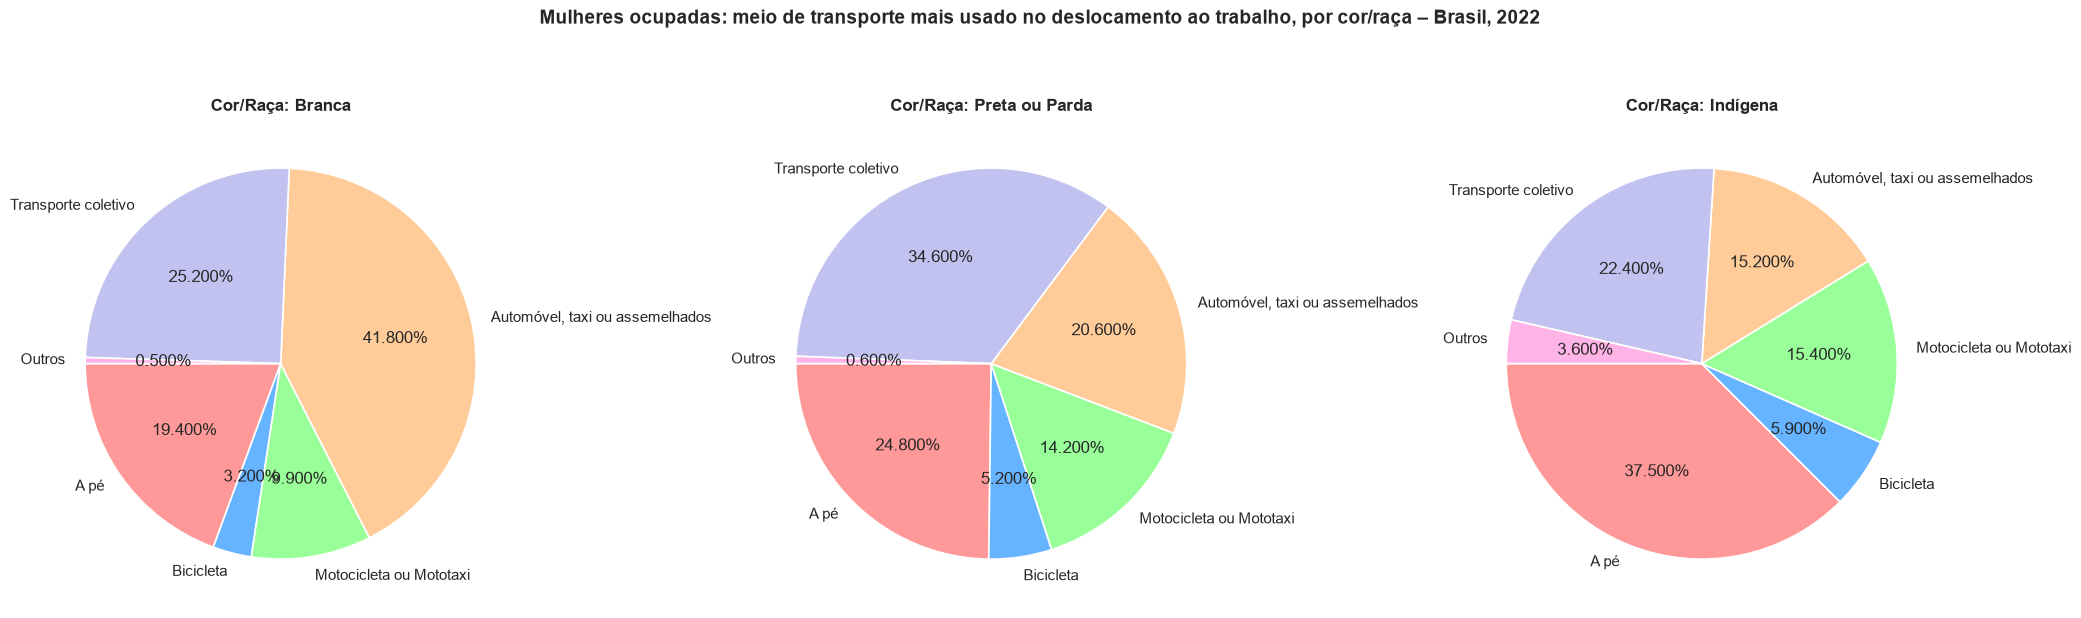

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Mulheres ocupadas: meio de transporte mais usado no deslocamento ao trabalho, por cor/raça – Brasil, 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

## Parte 2 – Brasil, Grandes Regiões, UFs e Municípios

In [5]:
raw = pd.read_excel(arquivo, sheet_name='BR GR UF MU', header=None, skiprows=3)

meios = ['A pé', 'Bicicleta', 'Motocicleta ou Mototaxi', 'Automóvel, taxi ou assemelhados', 'Transporte coletivo', 'Outros']
racas = ['Branca', 'Preta ou Parda', 'Indígena']

raw.columns = ['Local'] + [f'{r}|{m}' for r in racas for m in meios]
raw.head()

,Local,Branca|A pé,Branca|Bicicleta,Branca|Motocicleta ou Mototaxi,"Branca|Automóvel, taxi ou assemelhados",Branca|Transporte coletivo,Branca|Outros,Preta ou Parda|A pé,Preta ou Parda|Bicicleta,Preta ou Parda|Motocicleta ou Mototaxi,"Preta ou Parda|Automóvel, taxi ou assemelhados",Preta ou Parda|Transporte coletivo,Preta ou Parda|Outros,Indígena|A pé,Indígena|Bicicleta,Indígena|Motocicleta ou Mototaxi,"Indígena|Automóvel, taxi ou assemelhados",Indígena|Transporte coletivo,Indígena|Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26,0.6,42,4.2,19.4,13.1,20.6,0.7
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23,4.5,7,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
4,Sul,20.8,3.5,7.3,48,20,0.5,24,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1


In [6]:
i_ini = raw.index[raw['Local'] == 'Rondônia'][0]
i_fim = raw.index[raw['Local'] == 'Distrito Federal'][0]

estados = raw.loc[i_ini:i_fim].copy()
cidades = raw.loc[i_fim + 1:].copy()

print(len(estados))
estados['Local'].tolist()

27


['Rondônia',
 'Acre',
 'Amazonas',
 'Roraima',
 'Pará',
 'Amapá',
 'Tocantins',
 'Maranhão',
 'Piauí',
 'Ceará',
 'Rio Grande do Norte',
 'Paraíba',
 'Pernambuco',
 'Alagoas',
 'Sergipe',
 'Bahia',
 'Minas Gerais',
 'Espírito Santo',
 'Rio de Janeiro',
 'São Paulo',
 'Paraná',
 'Santa Catarina',
 'Rio Grande do Sul',
 'Mato Grosso do Sul',
 'Mato Grosso',
 'Goiás',
 'Distrito Federal']

In [7]:
def para_longo(base):
    longo = base.melt(id_vars='Local', var_name='chave', value_name='Percentual')
    longo[['Cor/Raça', 'Meio de Transporte']] = longo['chave'].str.split('|', expand=True)
    longo['Percentual'] = pd.to_numeric(longo['Percentual'], errors='coerce')
    return longo.drop(columns='chave')

estados_longo = para_longo(estados)
cidades_longo = para_longo(cidades)
estados_longo.head(10)

,Local,Percentual,Cor/Raça,Meio de Transporte
0,Rondônia,11.7,Branca,A pé
1,Acre,14.8,Branca,A pé
2,Amazonas,13.9,Branca,A pé
3,Roraima,11.6,Branca,A pé
4,Pará,17.5,Branca,A pé
5,Amapá,14.1,Branca,A pé
6,Tocantins,15.9,Branca,A pé
7,Maranhão,21.0,Branca,A pé
8,Piauí,18.2,Branca,A pé
9,Ceará,20.5,Branca,A pé


### 1) Qual estado tem mais mulheres, em geral, utilizando o transporte coletivo?

In [8]:
coletivo_uf = (
    estados_longo[estados_longo['Meio de Transporte'] == 'Transporte coletivo']
    .groupby('Local')['Percentual']
    .mean()
    .sort_values(ascending=False)
)

print(coletivo_uf.idxmax(), round(coletivo_uf.max(), 2))
coletivo_uf.head(5)

Rio de Janeiro 52.23


Local
Rio de Janeiro       52.233333
Distrito Federal     46.000000
São Paulo            40.733333
Rio Grande do Sul    36.100000
Sergipe              33.400000
Name: Percentual, dtype: float64

### 2) Qual estado tem menos mulheres, em geral, utilizando o transporte coletivo?

In [9]:
print(coletivo_uf.idxmin(), round(coletivo_uf.min(), 2))
coletivo_uf.tail(5)

Rondônia 4.33


Local
Mato Grosso    9.800000
Acre           9.200000
Tocantins      8.600000
Roraima        8.133333
Rondônia       4.333333
Name: Percentual, dtype: float64

### 3) Qual cidade do Brasil tem mais mulheres andando de bicicleta?

In [10]:
bike_cidade = (
    cidades_longo[cidades_longo['Meio de Transporte'] == 'Bicicleta']
    .groupby('Local')['Percentual']
    .agg(['mean', 'count'])
    .query('count == 3')['mean']
    .sort_values(ascending=False)
)

print(bike_cidade.idxmax(), round(bike_cidade.max(), 2))
bike_cidade.head(5)

Lagoa Grande (MG) 67.87


Local
Lagoa Grande (MG)              67.866667
Britânia (GO)                  64.466667
Bom Jesus do Tocantins (TO)    64.366667
Tumiritinga (MG)               63.866667
Cocalinho (MT)                 59.266667
Name: mean, dtype: float64

### 4) Qual cidade do Brasil tem mais mulheres utilizando carro?

In [11]:
carro_cidade = (
    cidades_longo[cidades_longo['Meio de Transporte'] == 'Automóvel, taxi ou assemelhados']
    .groupby('Local')['Percentual']
    .agg(['mean', 'count'])
    .query('count == 3')['mean']
    .sort_values(ascending=False)
)

print(carro_cidade.idxmax(), round(carro_cidade.max(), 2))
carro_cidade.head(5)

Bom Jesus (SC) 74.57


Local
Bom Jesus (SC)         74.566667
Valinhos (SP)          71.433333
Piratininga (SP)       71.400000
Nova Odessa (SP)       68.566667
Pinheiro Preto (SC)    68.433333
Name: mean, dtype: float64